# Reading a finished run

Figures for a pretraining run and for a probe. Everything is a thin call into
`sometria.viz`, so the plotting code lives in a module that reruns headless and this
notebook stays a viewer.

Two caveats the figures depend on:

- the reconstruction loss runs on **per-token standardized** targets, so the model
  predicts a patch's shape and never its magnitude. Error is plotted in that space; a
  raw joint-angle overlay would be showing scale the model was never asked for.
- there is **no confusion matrix** for a 60-way multilabel benchmark: a window carries
  several labels, so there is no single prediction to confuse. Per-label AP against
  prevalence is what answers the same question.

In [ ]:
%load_ext autoreload
%autoreload 2

import os

import matplotlib.pyplot as plt

from omegaconf import OmegaConf

from sometria.viz import (
    collect_predictions,
    dof_names,
    label_names,
    latest_checkpoint,
    load_run,
    per_label_ap,
    plot_channel_error,
    plot_label_ap,
    plot_prevalence_vs_ap,
    plot_reconstruction_grid,
    project_root,
)

# Run directories and the data paths inside each run's config are relative to the
# repository root; this notebook starts in notebooks/.
os.chdir(project_root())

PRETRAIN = "runs/ablation/pretrain/seed_13"
PROBE = "runs/channels/probe_attentive/channels_kin_all"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Pretraining: where the reconstruction error lives

### Per channel, over epochs

The plot the channels ablation argues from. `acc` and `tau` sit far above `sin` and
`cos` and barely move: most of the gradient, almost none of the learnable signal.

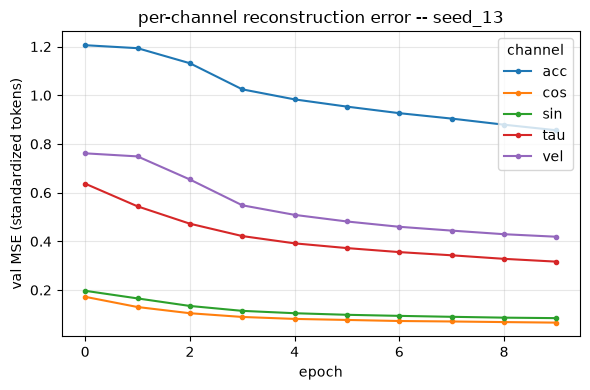

In [4]:
plot_channel_error(PRETRAIN);

### Per token, over the grid

One token is one DOF over `patch_size` frames, so the natural picture is the `T x D`
grid rather than a time series. Averaged over the batch, and only over the tokens that
were actually masked -- positions nothing masked come back NaN.

In [5]:
model, datamodule = load_run(PRETRAIN)
batch = next(iter(datamodule.val_dataloader()))

plot_reconstruction_grid(model, batch, dof_names(datamodule));

FileNotFoundError: [Errno 2] No such file or directory: 'config/human.yaml'

## 2. The probe: what the frozen representation can and cannot separate

Collected once, plotted twice. `limit` caps the batches while iterating; drop it for a
number that matches what `scripts/results.py` reports for the run.

In [ ]:
probe, labelled = load_run(PROBE)
config = OmegaConf.load(f"{PROBE}/config.yaml")
names = label_names(config.dataloader.root, config.dataloader.label_set)

logits, targets = collect_predictions(probe, labelled.val_dataloader())
scores = per_label_ap(logits, targets)
print(f"macro mAP {scores[~scores.isnan()].mean():.4f} over {(~scores.isnan()).sum()} labels present")

### Per-label AP, ordered by prevalence

The macro mAP, decomposed. The dashed line is each label's prevalence -- the AP a random
ranker scores -- so a bar under its own line is a label the probe reads no better than
the base rate.

In [ ]:
plot_label_ap(logits, targets, names);

### Prevalence against AP

The control for "did it only learn which actions are common". Points on the diagonal are
ranked at their base rate; a cloud that rises with prevalence and nothing else is a probe
reporting the label distribution back.

In [ ]:
plot_prevalence_vs_ap(logits, targets, names);